In [1]:
# These are "libraries" — collections of tools someone else built that you can use
# pandas: for loading and exploring tabular data (like Excel spreadsheets)
# matplotlib: for making plots/graphs
# seaborn: makes matplotlib plots look nicer with less code
# sklearn: contains many ML tools AND some built-in datasets (like Iris)

import pandas as pd                        # pd is just a shorthand nickname — everyone uses this
import matplotlib.pyplot as plt            # plt is the shorthand everyone uses
import seaborn as sns                      # sns is the shorthand everyone uses
from sklearn.datasets import load_iris     # this lets us load the Iris dataset without downloading anything

print("All libraries loaded successfully!")  # this line just confirms everything worked

All libraries loaded successfully!


In [2]:
# Load the Iris dataset from sklearn
# The Iris dataset measures 4 features of 150 flowers across 3 species
# This is a classic dataset used in biology + ML — real measurements from real flowers
iris_data = load_iris()

# Convert it into a pandas DataFrame
# A DataFrame is like an Excel spreadsheet — rows are samples, columns are features
df = pd.DataFrame(
    data=iris_data.data,                  # the actual numbers (measurements)
    columns=iris_data.feature_names       # the column names (what was measured)
)

# Add the species column — 0, 1, 2 represent the 3 flower species
df['species'] = iris_data.target

# Replace the numbers 0, 1, 2 with actual species names so it's readable
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print("Dataset loaded!")
print(f"Shape: {df.shape}")   # prints (rows, columns) — should say (150, 5)

Dataset loaded!
Shape: (150, 5)


In [3]:
# .head() shows the first 5 rows of your DataFrame
# This is always the FIRST thing you do with any new dataset
# It lets you see: what columns exist, what the data looks like, any obvious problems

print("First 5 rows of the dataset:")
df.head()    # in Colab, calling df.head() on the last line of a cell shows a nice table

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# .tail() shows the last 5 rows
# Useful to check if the data ends cleanly or has weird trailing rows

print("Last 5 rows:")
df.tail()

Last 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [5]:
# .describe() automatically calculates:
# count (how many non-empty values), mean (average), std (standard deviation),
# min, 25th percentile, 50th percentile (median), 75th percentile, max
# This gives you the "shape" of your data at a glance

print("Statistical summary:")
df.describe()

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# Real datasets almost always have missing values (empty cells)
# .isnull() marks every cell as True (missing) or False (has value)
# .sum() then counts how many True values exist per column

print("Missing values per column:")
print(df.isnull().sum())

# Also check data types of each column
print("\nData types:")
print(df.dtypes)

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


In [7]:
# .value_counts() counts how many rows belong to each category
# In gene expression terms: how many samples belong to each condition (cancer/normal, etc.)

print("Number of samples per species:")
print(df['species'].value_counts())

Number of samples per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


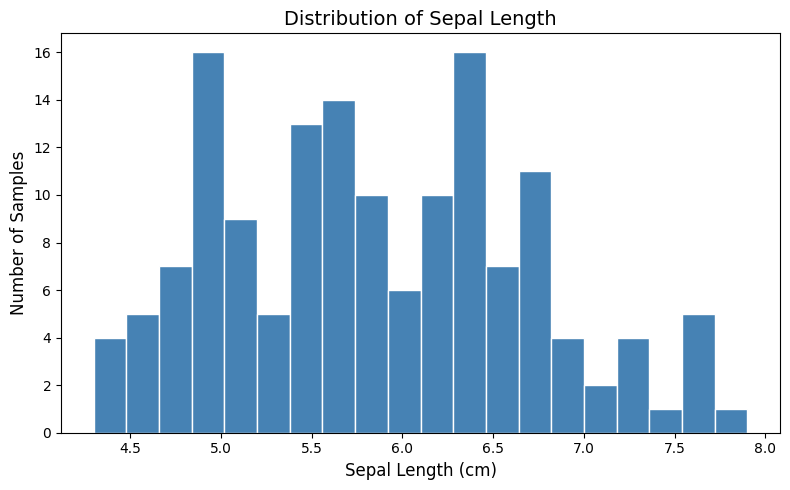

In [8]:
# A histogram shows the DISTRIBUTION of a single variable
# x-axis: value range, y-axis: how many samples fall in each range
# This tells you: is the data normally distributed? Are there outliers?

plt.figure(figsize=(8, 5))              # set the size of the figure (width, height in inches)

plt.hist(
    df['sepal length (cm)'],            # the column we're plotting
    bins=20,                            # divide the range into 20 buckets
    color='steelblue',                  # bar colour
    edgecolor='white'                   # thin white lines between bars for readability
)

plt.title('Distribution of Sepal Length', fontsize=14)    # title of the plot
plt.xlabel('Sepal Length (cm)', fontsize=12)              # x-axis label
plt.ylabel('Number of Samples', fontsize=12)              # y-axis label

plt.tight_layout()    # automatically adjusts spacing so nothing overlaps
plt.show()            # displays the plot

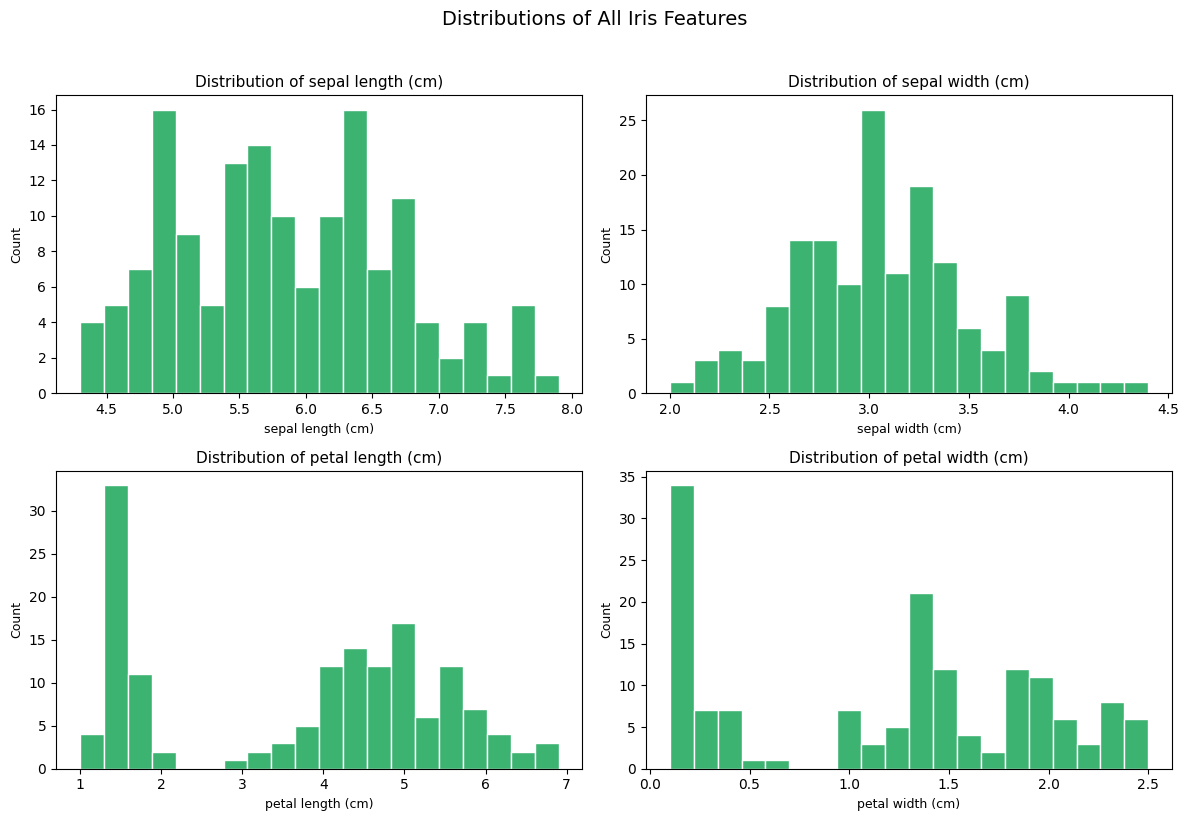

In [9]:
# Loop through all 4 measurement columns and plot a histogram for each
# This is the efficient way — instead of writing 4 separate plot blocks

fig, axes = plt.subplots(2, 2, figsize=(12, 8))   # create a 2x2 grid of 4 plots
axes = axes.flatten()                              # flatten the 2D grid into a simple list of 4

# List of columns to plot (the 4 measurement columns)
feature_columns = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

# Loop through each column and plot it in its own subplot
for i, column in enumerate(feature_columns):
    axes[i].hist(
        df[column],
        bins=20,
        color='mediumseagreen',
        edgecolor='white'
    )
    axes[i].set_title(f'Distribution of {column}', fontsize=11)
    axes[i].set_xlabel(column, fontsize=9)
    axes[i].set_ylabel('Count', fontsize=9)

plt.suptitle('Distributions of All Iris Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

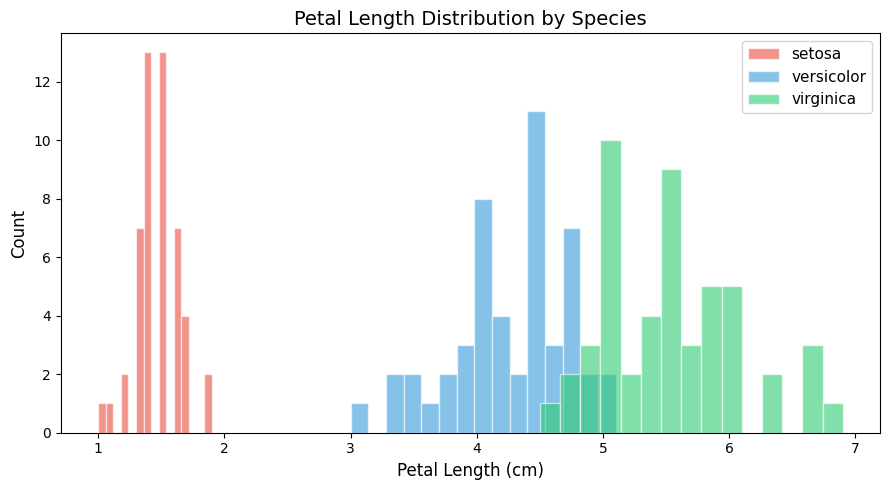

In [10]:
# This version overlays histograms for each species in different colours
# alpha=0.6 makes bars semi-transparent so overlapping bars are visible
# This immediately shows: do the 3 species have different measurements?

plt.figure(figsize=(9, 5))

# Get unique species names
species_list = df['species'].unique()

# Colours for each species
colours = ['#E74C3C', '#3498DB', '#2ECC71']

for species, colour in zip(species_list, colours):
    # Filter the DataFrame to only rows of this species
    subset = df[df['species'] == species]

    plt.hist(
        subset['petal length (cm)'],    # plotting petal length — most separable feature
        bins=15,
        alpha=0.6,                      # 0=fully transparent, 1=fully solid
        label=species,                  # label for the legend
        color=colour,
        edgecolor='white'
    )

plt.title('Petal Length Distribution by Species', fontsize=14)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=11)               # shows the colour-to-species key
plt.tight_layout()
plt.show()

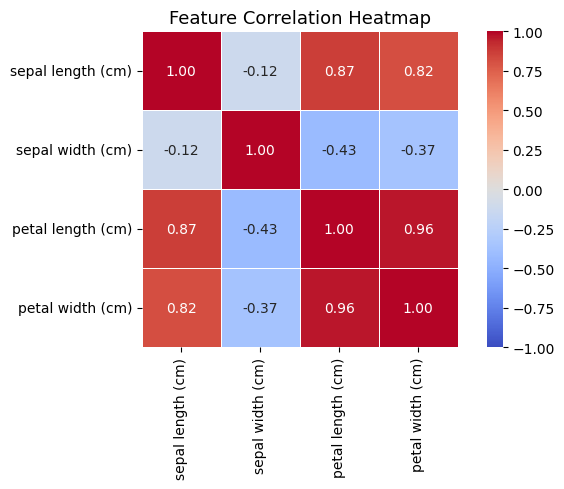

In [11]:
# A heatmap shows a matrix of values as colours
# In gene expression: rows = genes, columns = samples, colour = expression level
# Here: rows = features, columns = features, colour = correlation (-1 to +1)

# First, calculate the correlation between each pair of features
# Correlation = how much do two variables move together?
# +1 = perfect positive relationship, -1 = perfect negative, 0 = no relationship

correlation_matrix = df.drop('species', axis=1).corr()   # drop the text column first

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,           # write the actual number inside each cell
    fmt='.2f',            # format numbers to 2 decimal places
    cmap='coolwarm',      # colour scheme: blue=negative, red=positive correlation
    vmin=-1,              # minimum value on colour scale
    vmax=1,               # maximum value on colour scale
    square=True,          # make cells square not rectangular
    linewidths=0.5        # thin lines between cells
)

plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Save the DataFrame to a CSV file
# This creates a file inside your Colab session
df.to_csv('iris_explored.csv', index=False)   # index=False stops pandas adding a row number column

print("File saved as iris_explored.csv")

# Download it to your laptop
from google.colab import files
files.download('iris_explored.csv')           # this triggers an automatic browser download

File saved as iris_explored.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>